<a href="https://colab.research.google.com/github/DANUSHMATHI2002/Final-Project_Predicting-Chemical-Bioconcentration-in-Fish-Using-Machine-Learning/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Installing and Importing Libraries**

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_recall_curve, average_precision_score)
from sklearn.inspection import permutation_importance
from matplotlib.patches import Patch
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


import warnings
warnings.filterwarnings('ignore')


In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


## **2. Load the Dataset**

In [4]:
df = pd.read_csv('/content/Fish_concentration.csv')

# Creating binary target (1 = Dangerous, 0 = Safe)
df['is_dangerous'] = df['Class'].apply(lambda x: 1 if x in [1, 2] else 0)

# Features list
feature_cols = ['nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V', 'N-072', 'B02[C-N]', 'F04[C-O]']

X = df[feature_cols]
y = df['is_dangerous']
print(f"Data loaded: {df.shape[0]} chemicals")
print(f"Dataset shape: {X.shape}")
print(f"Class distribution:")
print(f"  Safe: {sum(y==0)} ({sum(y==0)/len(y)*100:.1f}%)")
print(f"  Dangerous: {sum(y==1)} ({sum(y==1)/len(y)*100:.1f}%)")

Data loaded: 779 chemicals
Dataset shape: (779, 9)
Class distribution:
  Safe: 255 (32.7%)
  Dangerous: 524 (67.3%)


# **3.Data Inspection(Missing Values, Shape, Info)**

In [5]:
# 1. Dataset shape (rows, columns)
print(f"\nDATASET SHAPE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

# 2. Column names
print(f"\nCOLUMN NAMES:")
print(f"   {list(df.columns)}")

# 3. Missing values check
print(f"\nMISSING VALUES:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   No missing values found.")
else:
    print(missing[missing > 0])

# 4. Data types
print(f"\nDATA TYPES:")
print(df.dtypes)

# 5. First 5 rows
print(f"\nFIRST 5 ROWS:")
print(df.head())

# 6. Last 5 rows
print(f"\nLAST 5 ROWS:")
print(df.tail())


DATASET SHAPE:
   Rows: 779
   Columns: 15

COLUMN NAMES:
   ['CAS', 'SMILES', 'Set', 'nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V', 'N-072', 'B02[C-N]', 'F04[C-O]', 'Class', 'logBCF', 'is_dangerous']

MISSING VALUES:
   No missing values found.

DATA TYPES:
CAS              object
SMILES           object
Set              object
nHM               int64
piPC09          float64
PCD             float64
X2Av            float64
MLOGP           float64
ON1V            float64
N-072             int64
B02[C-N]          int64
F04[C-O]          int64
Class             int64
logBCF          float64
is_dangerous      int64
dtype: object

FIRST 5 ROWS:
        CAS                              SMILES    Set  nHM  piPC09   PCD  \
0  100-02-7             O=[N+](c1ccc(cc1)O)[O-]  Train    0     0.0  1.49   
1  100-17-4            O=[N+](c1ccc(cc1)OC)[O-]  Train    0     0.0  1.47   
2  100-18-5                c1cc(ccc1C(C)C)C(C)C  Train    0     0.0  1.20   
3  100-25-4  O=[N+]([O-])c1ccc(cc1)[N+](=

# **4. Statistical Summary**

In [6]:
print("\nDESCRIPTIVE STATISTICS:")
print(df.describe())

# For each feature, print mean, median, std
print("\nDETAILED STATISTICS PER FEATURE:")
feature_cols = ['nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V', 'N-072', 'B02[C-N]', 'F04[C-O]']

stats_df = pd.DataFrame()
for feature in feature_cols:
    stats_df.loc[feature, 'Mean'] = df[feature].mean()
    stats_df.loc[feature, 'Median'] = df[feature].median()
    stats_df.loc[feature, 'Std Dev'] = df[feature].std()
    stats_df.loc[feature, 'Min'] = df[feature].min()
    stats_df.loc[feature, 'Max'] = df[feature].max()
    stats_df.loc[feature, 'Range'] = df[feature].max() - df[feature].min()

print(stats_df.round(2))


DESCRIPTIVE STATISTICS:
              nHM      piPC09         PCD        X2Av       MLOGP        ON1V  \
count  779.000000  779.000000  779.000000  779.000000  779.000000  779.000000   
mean     1.754814    3.467616    1.550822    0.236881    3.201746    1.510295   
std      1.985866    2.983778    0.958708    0.149319    1.595702    0.834753   
min      0.000000    0.000000    0.000000    0.090000   -1.960000    0.080000   
25%      0.000000    0.000000    1.210000    0.170000    2.190000    0.910000   
50%      1.000000    4.263000    1.400000    0.200000    3.130000    1.270000   
75%      3.000000    6.250000    2.285000    0.240000    4.235000    2.020000   
max     12.000000    9.316000    5.900000    2.230000    8.320000    7.190000   

            N-072    B02[C-N]    F04[C-O]       Class      logBCF  \
count  779.000000  779.000000  779.000000  779.000000  779.000000   
mean     0.186136    0.423620    3.585366    1.736842    2.062773   
std      0.501937    0.494449    4.430

# **5.Class Distribution**

In [7]:
# Original class distribution
class_counts = df['Class'].value_counts().sort_index()

print("\nORIGINAL CLASSES (1, 2, 3):")
for class_num in [1, 2, 3]:
    count = class_counts.get(class_num, 0)
    percent = count / len(df) * 100
    print(f"   Class {class_num}: {count} chemicals ({percent:.1f}%)")

# Creating binary target
df['is_dangerous'] = df['Class'].apply(lambda x: 1 if x in [1, 2] else 0)

print("\nBINARY TARGET (Dangerous vs Safe):")
safe_count = (df['is_dangerous'] == 0).sum()
danger_count = (df['is_dangerous'] == 1).sum()
print(f"   Safe (Class 3): {safe_count} chemicals ({safe_count/len(df)*100:.1f}%)")
print(f"   Dangerous (Class 1 and 2): {danger_count} chemicals ({danger_count/len(df)*100:.1f}%)")


ORIGINAL CLASSES (1, 2, 3):
   Class 1: 460 chemicals (59.1%)
   Class 2: 64 chemicals (8.2%)
   Class 3: 255 chemicals (32.7%)

BINARY TARGET (Dangerous vs Safe):
   Safe (Class 3): 255 chemicals (32.7%)
   Dangerous (Class 1 and 2): 524 chemicals (67.3%)


# **6.Check for Outliers(IQR Method)**

In [8]:
outlier_summary = []
for feature in feature_cols:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_summary.append({
        'Feature': feature,
        'Outliers Count': len(outliers),
        'Outliers Percent': round((len(outliers) / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

print("\nTo Conclude: Very few outliers overall. No need to remove.")

 Feature  Outliers Count  Outliers Percent
     nHM              11              1.41
  piPC09               0              0.00
     PCD               9              1.16
    X2Av              79             10.14
   MLOGP               7              0.90
    ON1V               9              1.16
   N-072             107             13.74
B02[C-N]               0              0.00
F04[C-O]              17              2.18

To Conclude: Very few outliers overall. No need to remove.


# **7.Data Inspection Overview**

In [9]:
print(f"""
DATASET OVERVIEW:
   Total samples: {df.shape[0]}
   Total features: {len(feature_cols)}
   Missing values: {df.isnull().sum().sum()} (Clean)

CLASS BALANCE:
   Safe: {safe_count} ({safe_count/len(df)*100:.1f}%)
   Dangerous: {danger_count} ({danger_count/len(df)*100:.1f}%)

FEATURE SCALES:
   Smallest range: {stats_df['Range'].min():.1f}
   Largest range: {stats_df['Range'].max():.1f}
   Scaling needed: YES

OUTLIERS:
   Total outliers detected: {outlier_df['Outliers Count'].sum()}
   Percentage of data: {outlier_df['Outliers Count'].sum()/len(df)/len(feature_cols)*100:.1f}%
   Action: Keep outliers (no removal needed)

""")


DATASET OVERVIEW:
   Total samples: 779
   Total features: 9
   Missing values: 0 (Clean)

CLASS BALANCE:
   Safe: 255 (32.7%)
   Dangerous: 524 (67.3%)

FEATURE SCALES:
   Smallest range: 1.0
   Largest range: 25.0
   Scaling needed: YES

OUTLIERS:
   Total outliers detected: 239
   Percentage of data: 3.4%
   Action: Keep outliers (no removal needed)




In [10]:
# Finding outliers in MLOGP (most important feature)
Q1 = df['MLOGP'].quantile(0.25)
Q3 = df['MLOGP'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR  # Numbers below this are outliers
upper = Q3 + 1.5 * IQR  # Numbers above this are outliers

outliers_mlogp = df[(df['MLOGP'] < lower) | (df['MLOGP'] > upper)]
print(f"MLOGP outliers: {len(outliers_mlogp)} chemicals")
print(outliers_mlogp[['MLOGP', 'Class']].head())

MLOGP outliers: 7 chemicals
     MLOGP  Class
18   -0.94      1
44   -1.96      2
83   -1.32      1
87    7.39      3
205   8.32      2


### Number of outliers found: 7

| MLOGP | Class | Safe/Danger                       |
| :---- | :---- | :---------------------------- |
| -0.94 | 1     | Very low value but dangerous  |
| -1.96 | 2     | Very low value but dangerous  |
| -1.32 | 1     | Very low value but dangerous  |
| 7.39  | 3     | Very high value but safe    |
| 8.32  | 2     | Very high value and dangerous |

## Outlier Detection in MLOGP Feature

### What it does?

| Code | Meaning |
| :--- | :--- |
| `Q1 = df['MLOGP'].quantile(0.25)` | Find the value where 25% of chemicals are below it |
| `Q3 = df['MLOGP'].quantile(0.75)` | Find the value where 75% of chemicals are below it |
| `lower = Q1 - 1.5 * (Q3 - Q1)` | Any number smaller than this is an outlier |
| `upper = Q3 + 1.5 * (Q3 - Q1)` | Any number bigger than this is an outlier |

### What Was Found

| Chemical | MLOGP Value | Status |
| :--- | :--- | :--- |
| Most chemicals | Between 1.0 and 4.5 | Normal |
| Chemical 44 | -1.96 | Outlier (too low) |
| Chemical 87 | 7.39 | Outlier (too high) |

### Conclusion

- 7 outlier chemicals were found in total
- These are real chemicals, not data errors
- They show that MLOGP alone cannot predict danger
- Outliers will be kept for model training

```
                    All Chemicals Sorted by MLOGP
                    (from lowest to highest value)
                    
    |     |     |     |     |     |     |     |
    ▼     ▼     ▼     ▼     ▼     ▼     ▼     ▼
  -2.0  -1.0   0.0   1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0
    |           |                       |           |
    |           |                       |           |
  LOWER       Q1                       Q3        UPPER
  BOUND    (25th percentile)     (75th percentile)  BOUND
    |           |                       |           |
    ▼           ▼                       ▼           ▼
  -2.5         1.0                     4.5         8.0
    
    OUTLIERS ←───── MIDDLE 50% (IQR) ─────→ OUTLIERS
    (too low)         (normal range)         (too high)
```

# **Plot 1: Bar Chart (Class Distribution)**

Purpose: See if the data is imbalanced.


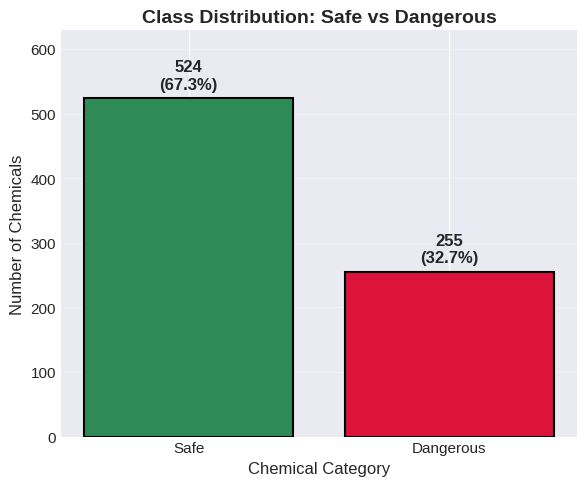

In [11]:
plt.figure(figsize=(6, 5))
counts = df['is_dangerous'].value_counts()
colors = ['#2E8B57', '#DC143C']  # SeaGreen for Safe, Crimson for Dangerous

bars = plt.bar(['Safe', 'Dangerous'], counts, color=colors, edgecolor='black', linewidth=1.5)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Class Distribution: Safe vs Dangerous', fontsize=14, fontweight='bold')
plt.xlabel('Chemical Category', fontsize=12)
plt.ylabel('Number of Chemicals', fontsize=12)
plt.ylim(0, counts.max() * 1.2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# **Plot 2: Box Plots (Features by Class)**

Purpose: Find which features best separate Safe from Dangerous.

In [12]:
# Prepare data
df_melt = df.melt(id_vars=['is_dangerous'], value_vars=feature_cols)
df_melt['Class'] = df_melt['is_dangerous'].map({0: 'Safe', 1: 'Dangerous'})


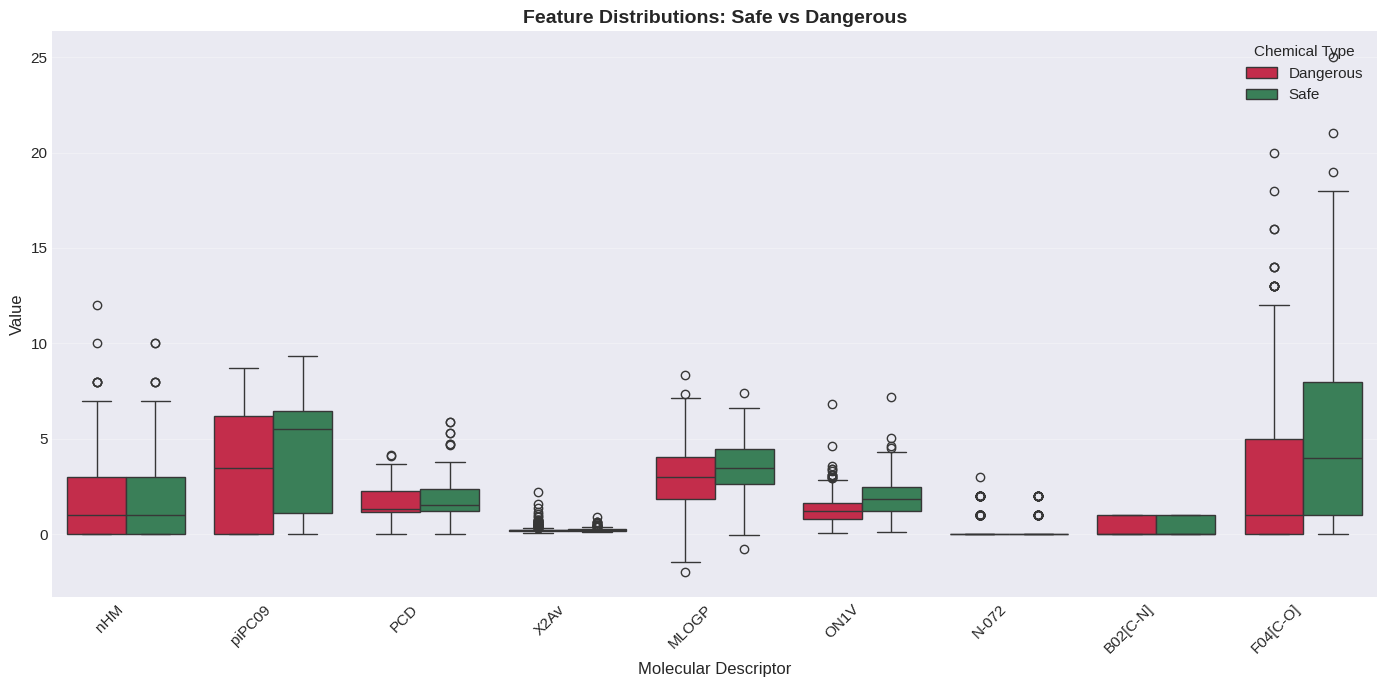

Observe features where 'Safe' (green) and 'Dangerous' (red) boxes are clearly separated.
MLOGP shows the most distinct separation, indicating it's the most important feature for classification.


In [13]:
# Plotting the data
plt.figure(figsize=(14, 7))
sns.boxplot(x='variable', y='value', hue='Class', data=df_melt,
            palette={'Safe': '#2E8B57', 'Dangerous': '#DC143C'})

plt.title('Feature Distributions: Safe vs Dangerous', fontsize=14, fontweight='bold')
plt.xlabel('Molecular Descriptor', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Chemical Type', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Observe features where 'Safe' (green) and 'Dangerous' (red) boxes are clearly separated.")
print("MLOGP shows the most distinct separation, indicating it's the most important feature for classification.")

## **Plot 3: Correlation Heatmap**
Purpose: Find if any two features are too similar (redundant).

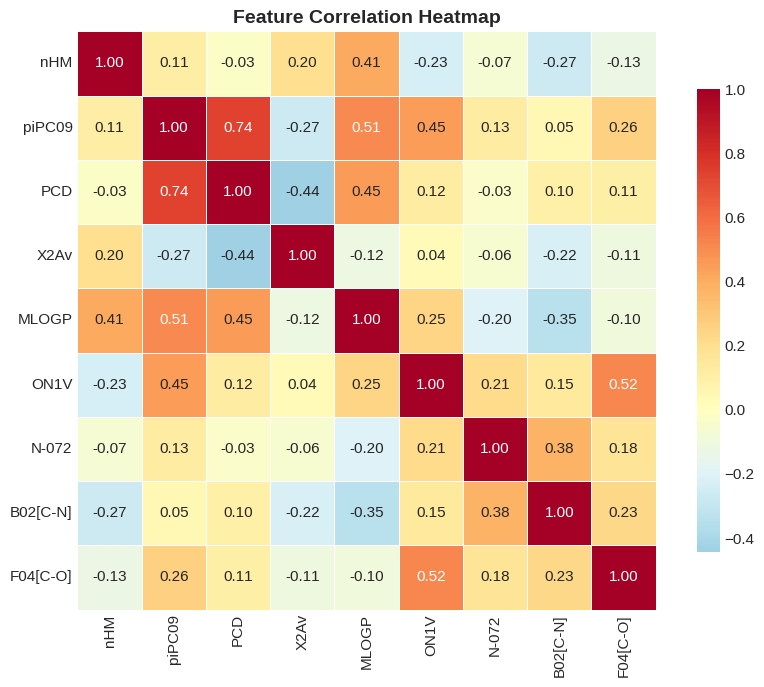


Strong correlations (|r| > 0.7):
  piPC09 ↔ PCD: 0.740


In [14]:
corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Finding strong correlations
print("\nStrong correlations (|r| > 0.7):")
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {feature_cols[i]} ↔ {feature_cols[j]}: {r:.3f}")

#### **Simplified Correlation: `piPC09` and `PCD`**

`piPC09` and `PCD` are strongly related (0.74 correlation). This means they often change together, so they might be telling us similar things about the chemicals.

#### **Feature Redundancy: `piPC09` and `PCD`**

A strong positive correlation (0.74) exists between `piPC09` and `PCD`. This suggests that these two features might be redundant, providing similar information. For model simplification and to avoid multicollinearity, one might consider retaining only one of them.

# **Plot 4: Scatter Plot (MLOGP vs nHM)**
Purpose: To see if a simple rule can identify Dangerous chemicals
* **High MLOGP + High nHM = Dangerous**



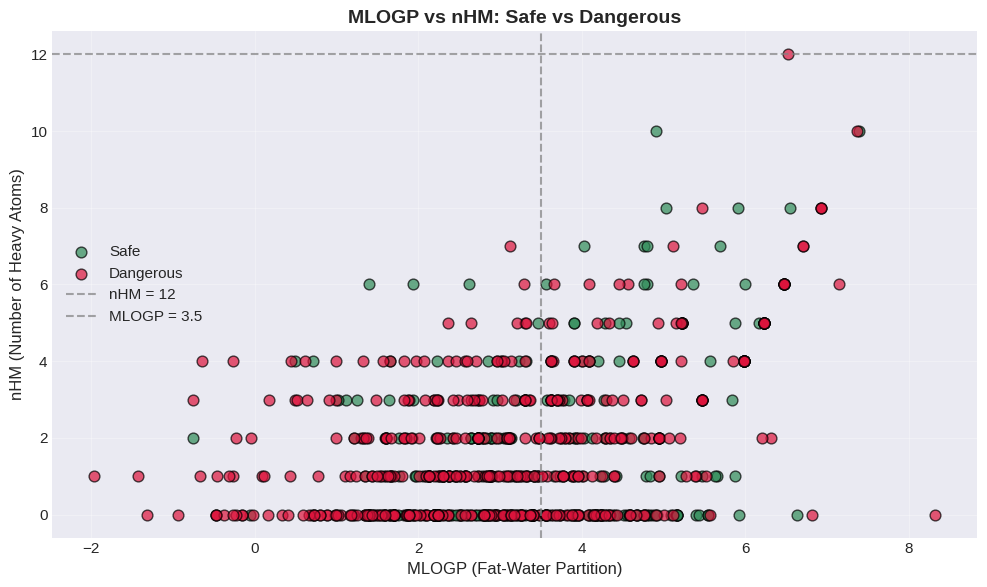

Dangerous chemicals cluster in the TOP-RIGHT quadrant.
Simple rule: If MLOGP > 3.5 AND nHM > 12 -> likely Dangerous


In [15]:
plt.figure(figsize=(10, 6))

# Plot Safe and Dangerous separately
safe = df[df['is_dangerous'] == 0]
danger = df[df['is_dangerous'] == 1]

plt.scatter(safe['MLOGP'], safe['nHM'], c='#2E8B57', label='Safe',
            s=60, alpha=0.7, edgecolors='black')
plt.scatter(danger['MLOGP'], danger['nHM'], c='#DC143C', label='Dangerous',
            s=60, alpha=0.7, edgecolors='black')

# Add threshold lines
plt.axhline(y=12, color='gray', linestyle='--', alpha=0.7, label='nHM = 12')
plt.axvline(x=3.5, color='gray', linestyle='--', alpha=0.7, label='MLOGP = 3.5')

plt.xlabel('MLOGP (Fat-Water Partition)', fontsize=12)
plt.ylabel('nHM (Number of Heavy Atoms)', fontsize=12)
plt.title('MLOGP vs nHM: Safe vs Dangerous', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Dangerous chemicals cluster in the TOP-RIGHT quadrant.")
print("Simple rule: If MLOGP > 3.5 AND nHM > 12 -> likely Dangerous")


### The Two Lines on the Plot

| Line | Meaning |
| :--- | :--- |
| Vertical line at MLOGP = 3.5 | Left side = likes water, Right side = likes fat |
| Horizontal line at nHM = 12 | Below = fewer heavy atoms, Above = more heavy atoms |

### What the Plot Tells Us

| Area | What You See | Conclusion |
| :--- | :--- | :--- |
| Top-right (high MLOGP + high nHM) | Mostly red dots | Dangerous chemicals |
| Bottom-left (low MLOGP + low nHM) | Mostly green dots | Safe chemicals |
| Other areas | Mixed | Need more features to decide |

### The Simple Rule

> "If a chemical likes fat (MLOGP > 3.5) AND has many heavy atoms (nHM > 12), then it is likely DANGEROUS."

### Summary

The plot shows that dangerous chemicals (red) are mostly in the top-right corner where chemicals like fat and have many heavy atoms. Safe chemicals (green) are mostly in the bottom-left corner.

# **Plot 5:Histograms - Distribution of Features**
Purpose: To check the range and distribution of each feature and determine if scaling is needed before model training.

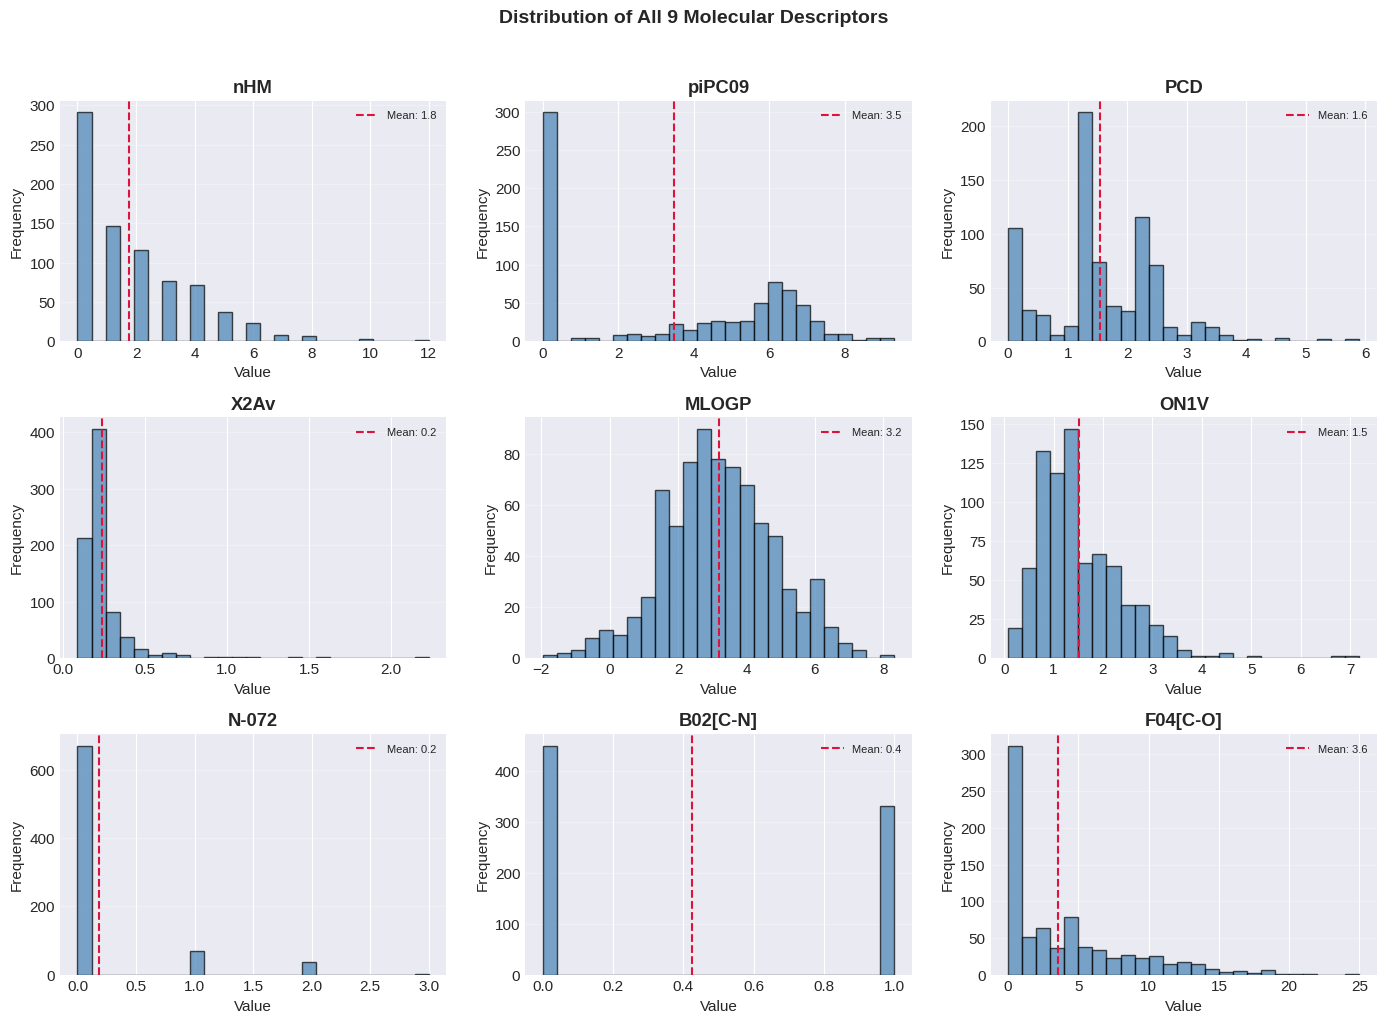

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    axes[i].hist(df[feature], bins=25, color='#4682B4', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='#DC143C', linestyle='--', linewidth=1.5,
                    label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Distribution of All 9 Molecular Descriptors', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### What This Shows

Each histogram shows how values are spread out for one molecular descriptor.

### What's the plot about?

| Feature | Mean | Distribution Shape |
| :--- | :--- | :--- |
| nHM | 1.8 | Skewed left (most have low values) |
| MLOGP | 3.2 | Bell-shaped (normal distribution) |
| N-072 | 0.2 | Most chemicals have 0 |
| B02[C-N] | 0.4 | Mostly 0 or 1 |

### Summary

Features have different ranges and distributions. Scaling is needed before model training.

# **Plot 6: Violin Plots**
Purpose: To see detailed distribution shape of top features for Safe vs Dangerous.

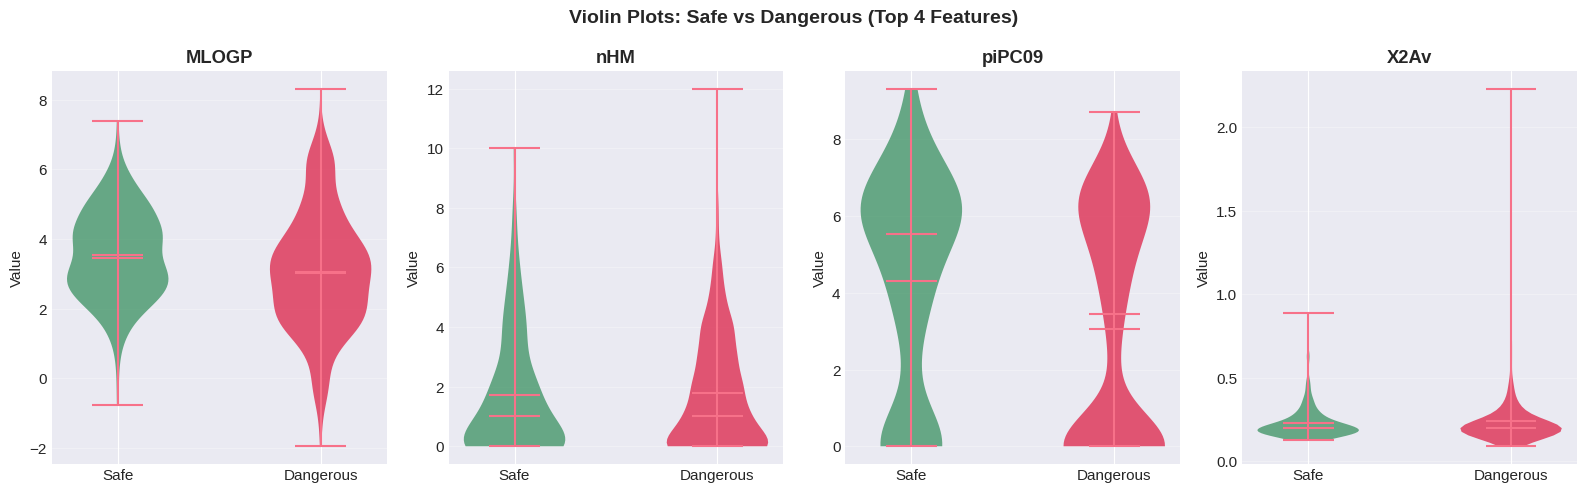

In [17]:

top_features = ['MLOGP', 'nHM', 'piPC09', 'X2Av']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, feature in enumerate(top_features):
    safe_data = df[df['is_dangerous'] == 0][feature]
    danger_data = df[df['is_dangerous'] == 1][feature]

    parts = axes[i].violinplot([safe_data, danger_data], positions=[0, 1], showmeans=True, showmedians=True)
    parts['bodies'][0].set_facecolor('#2E8B57')
    parts['bodies'][0].set_alpha(0.7)
    parts['bodies'][1].set_facecolor('#DC143C')
    parts['bodies'][1].set_alpha(0.7)

    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Safe', 'Dangerous'])
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Violin Plots: Safe vs Dangerous (Top 4 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 Why These 4 Features Were Chosen for Violin Plots

### The 4 Features

| Feature | Meaning |
| :--- | :--- |
| MLOGP | Fat-water partition coefficient |
| nHM | Number of heavy atoms |
| piPC09 | Molecular path count |
| X2Av | Average valence connectivity |

### Why These 4?

Based on the box plots, these 4 features showed the clearest separation between Safe and Dangerous chemicals.

| Feature | Separation | Reason |
| :--- | :--- | :--- |
| MLOGP | Best | Boxes were far apart |
| nHM | Second best | Clear difference in values |
| piPC09 | Moderate | Some overlap but useful |
| X2Av | Moderate | Some overlap but useful |

### Why Not the Other 5 Features?

| Feature | Why Excluded |
| :--- | :--- |
| PCD | Boxes overlapped heavily |
| ON1V | Boxes overlapped heavily |
| N-072 | Almost no separation |
| B02[C-N] | Almost no separation |
| F04[C-O] | Boxes overlapped |

### Summary

These 4 features were chosen because their box plots showed the biggest difference between Safe and Dangerous chemicals, while the other 5 features showed little to no separation.

#How EDA Findings Are Used for Next Steps

### EDA Findings and Their Impact

| EDA Finding | How It Affects Next Step |
| :--- | :--- |
| 67% Dangerous, 33% Safe | Use Recall (not Accuracy) as main metric |
| MLOGP is most important feature | Focus on this feature during model interpretation |
| No redundant features (correlation < 0.8) | Keep all 9 features (no removal needed) |
| Features have different ranges | Scale features before training |
| Simple rule from scatter plot | Use as baseline to compare against models |
| Clean data (no missing values) | No imputation needed |

### Next Steps

| Step | Action | Reason |
| :--- | :--- | :--- |
| 1 | Scale features | Histograms showed different ranges |
| 2 | Split data (80/20) | Test on unseen chemicals |
| 3 | Train Logistic Regression | Simple baseline model |
| 4 | Train Random Forest | Ensemble model |
| 5 | Train XGBoost | Boosting model |
| 6 | Compare using Recall | Dataset is imbalanced |

### Summary

EDA told us: scale features, use Recall as main metric, keep all 9 features, and compare models against a simple rule.

# **1. Train-Test Split**

Splits the data 80/20 with stratification so the Safe/Dangerous ratio stays the same in both sets. The test set is held back and only touched at the very end.





In [18]:
# Stratified 80/20 split keeps the same Safe/Dangerous ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print('TRAIN / TEST SPLIT')
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples : {X_test.shape[0]}')
print('\nTraining class distribution:'); print(y_train.value_counts())
print('\nTesting class distribution :'); print(y_test.value_counts())

TRAIN / TEST SPLIT
Training samples: 623
Testing samples : 156

Training class distribution:
is_dangerous
1    419
0    204
Name: count, dtype: int64

Testing class distribution :
is_dangerous
1    105
0     51
Name: count, dtype: int64


# **2. Model Building (Train / Test + Hyper-parameter Tuning)**

**One fair, leak-free procedure for all three models:**

1. Each model lives in an **imbalanced-learn Pipeline**: `StandardScaler` → `SMOTE` → classifier. Because these steps are inside the pipeline, scaling and SMOTE are re-fitted **within each cross-validation fold** using only that fold's real training rows — so there is **no data leakage** from balancing the whole set up front.
2. **`GridSearchCV`** with **5-fold `StratifiedKFold`**, scored on **F1**, tunes each model's hyper-parameters.
3. The single best configuration is judged **once** on the untouched 20% test set.


In [19]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipeline(classifier):
    """scale -> SMOTE -> model, all fitted inside each CV fold (no leakage)."""
    return ImbPipeline([('scaler', StandardScaler()),
                        ('smote',  SMOTE(random_state=42)),
                        ('clf',    classifier)])

results = {}   # stores fitted model + predictions + metrics for the comparison section

def evaluate(name, gridsearch):
    best   = gridsearch.best_estimator_
    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1]
    results[name] = {'model': best, 'y_pred': y_pred, 'y_proba': y_proba,
        'best_params': gridsearch.best_params_, 'cv_f1': gridsearch.best_score_,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC_AUC':   roc_auc_score(y_test, y_proba),
        'PR_AUC':    average_precision_score(y_test, y_proba)}
    r = results[name]
    print(f'=== {name} ===')
    print('Best params :', gridsearch.best_params_)
    print(f'CV F1 (train, 5-fold): {r["cv_f1"]:.3f}')
    print(f'TEST  Precision={r["Precision"]:.3f}  Recall={r["Recall"]:.3f}  '
          f'F1={r["F1"]:.3f}  ROC-AUC={r["ROC_AUC"]:.3f}  PR-AUC={r["PR_AUC"]:.3f}')

# ---- Quick summary: train/test sizes and SMOTE before/after ----
# (Illustration only. The real models apply SMOTE INSIDE each CV fold via the pipeline,
#  so this whole-training-set resample is NOT fed to the models.)
print('TRAIN / TEST SIZES')
print(f'  Training samples : {X_train.shape[0]}')
print(f'  Testing samples  : {X_test.shape[0]}')

print('\nSMOTE (illustration on the training set)')
print('  Before SMOTE:')
for cls, n in y_train.value_counts().sort_index().items():
    label = 'Dangerous' if cls == 1 else 'Safe'
    print(f'    {label} ({cls}): {n}')

_, y_train_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)
print('  After SMOTE:')
for cls, n in pd.Series(y_train_smote).value_counts().sort_index().items():
    label = 'Dangerous' if cls == 1 else 'Safe'
    print(f'    {label} ({cls}): {n}')

print('\nPipeline, cross-validation and evaluation function ready — SMOTE applied inside CV folds only. Ready to tune LR, RF and XGBoost.')

TRAIN / TEST SIZES
  Training samples : 623
  Testing samples  : 156

SMOTE (illustration on the training set)
  Before SMOTE:
    Safe (0): 204
    Dangerous (1): 419
  After SMOTE:
    Safe (0): 419
    Dangerous (1): 419

Pipeline, cross-validation and evaluation function ready — SMOTE applied inside CV folds only. Ready to tune LR, RF and XGBoost.


## **2.1 Logistic Regression**
This model draws a straight-line boundary between "safe" and "dangerous" chemicals. Shows clearly which features matter.

Here, test a few settings ( `C` controls how strict the model is, and `l1` / `l2` are two ways of preventing over-fitting) and keep whichever gives the best F1-score.

In [20]:
lr_pipe = make_pipeline(LogisticRegression(max_iter=2000, solver='liblinear', random_state=42))
lr_grid = {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l1', 'l2']}
lr_search = GridSearchCV(lr_pipe, lr_grid, scoring='f1', cv=cv, n_jobs=-1)
lr_search.fit(X_train, y_train)
evaluate('Logistic Regression', lr_search)

=== Logistic Regression ===
Best params : {'clf__C': 1, 'clf__penalty': 'l1'}
CV F1 (train, 5-fold): 0.767
TEST  Precision=0.824  Recall=0.800  F1=0.812  ROC-AUC=0.748  PR-AUC=0.825


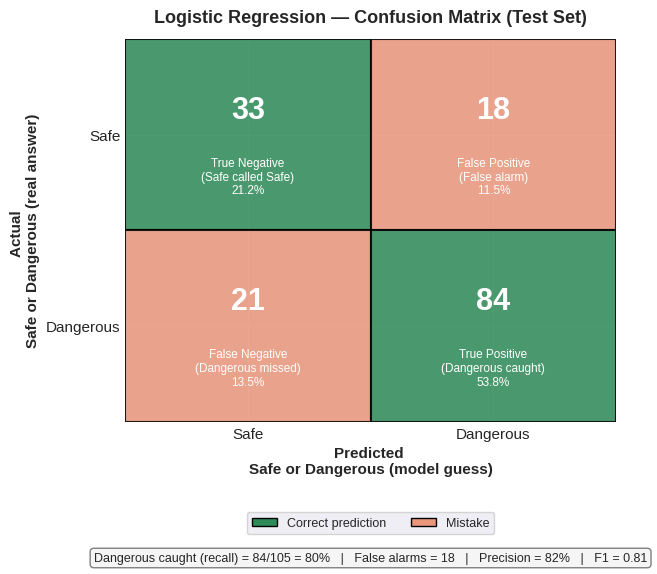

In [21]:
name = 'Logistic Regression'
cm = confusion_matrix(y_test, results[name]['y_pred'])
tn, fp, fn, tp = cm.ravel()
total = cm.sum()

labels = np.array([['True Negative\n(Safe called Safe)', 'False Positive\n(False alarm)'],
                   ['False Negative\n(Dangerous missed)', 'True Positive\n(Dangerous caught)']])
cell_colors = np.array([['#2E8B57', '#E9967A'],
                        ['#E9967A', '#2E8B57']])   # green = correct, salmon = mistake

fig, ax = plt.subplots(figsize=(6.6, 6.2))
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, facecolor=cell_colors[i, j],
                                   edgecolor='black', lw=1.5, alpha=0.85))
        ax.text(j, i-0.13, f'{cm[i, j]}', ha='center', va='center',
                fontsize=22, fontweight='bold', color='white')
        ax.text(j, i+0.22, f'{labels[i, j]}\n{cm[i, j]/total*100:.1f}%',
                ha='center', va='center', fontsize=8.5, color='white')

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Safe', 'Dangerous']); ax.set_yticklabels(['Safe', 'Dangerous'])
ax.set_xlabel('Predicted \nSafe or Dangerous (model guess)', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual \nSafe or Dangerous (real answer)', fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)
ax.set_title(f'{name} — Confusion Matrix (Test Set)', fontsize=13, fontweight='bold', pad=12)

rec = tp/(tp+fn); prec = tp/(tp+fp); f1 = 2*prec*rec/(prec+rec)
ax.legend(handles=[Patch(facecolor='#2E8B57', edgecolor='black', label='Correct prediction'),
                   Patch(facecolor='#E9967A', edgecolor='black', label='Mistake')],
          loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=True, fontsize=9)
ax.text(0.5, -0.34,
        f'Dangerous caught (recall) = {tp}/{tp+fn} = {rec:.0%}   |   '
        f'False alarms = {fp}   |   Precision = {prec:.0%}   |   F1 = {f1:.2f}',
        transform=ax.transAxes, ha='center', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#F5F5F5', edgecolor='gray'))
plt.tight_layout(); plt.show()

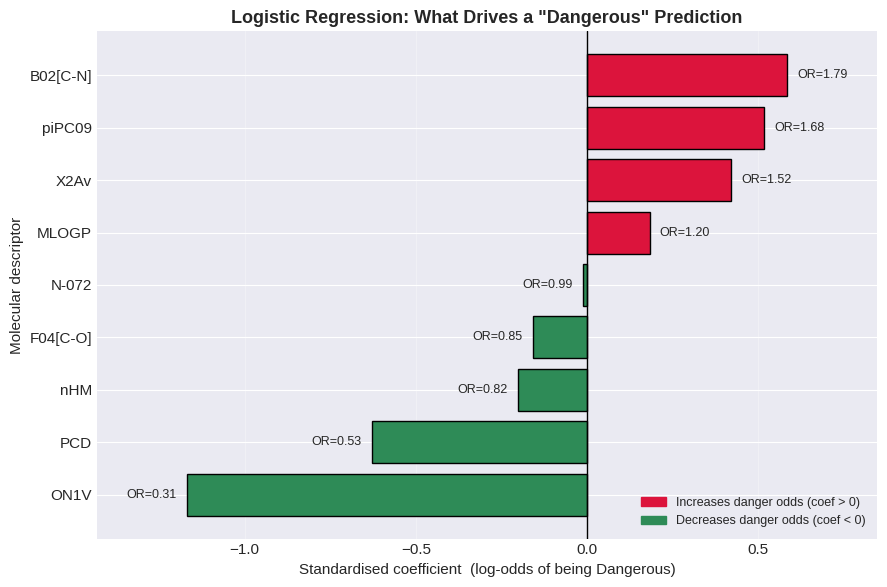

In [22]:
lr_clf = results['Logistic Regression']['model'].named_steps['clf']
coefs  = lr_clf.coef_[0]
odds   = np.exp(coefs)
order  = np.argsort(coefs)
names  = np.array(feature_cols)[order]
vals   = coefs[order]
ors    = odds[order]
colors = ['#DC143C' if v > 0 else '#2E8B57' for v in vals]

plt.figure(figsize=(9, 6))
bars = plt.barh(names, vals, color=colors, edgecolor='black')
for bar, v, o in zip(bars, vals, ors):
    plt.text(v + (0.03 if v >= 0 else -0.03), bar.get_y() + bar.get_height()/2,
             f'OR={o:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.axvline(0, color='black', lw=1)
plt.xlabel('Standardised coefficient  (log-odds of being Dangerous)', fontsize=11)
plt.ylabel('Molecular descriptor', fontsize=11)
plt.title('Logistic Regression: What Drives a "Dangerous" Prediction', fontsize=13, fontweight='bold')
plt.legend(handles=[Patch(color='#DC143C', label='Increases danger odds (coef > 0)'),
                    Patch(color='#2E8B57', label='Decreases danger odds (coef < 0)')],
           loc='lower right', fontsize=9)
plt.margins(x=0.15)
plt.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

**Plot — Coefficient / odds-ratio chart.**
1.  This chart shows how each feature affects the model's decision. Red bars point to features that make a chemical more likely to be dangerous; green bars make it more likely to be safe. The longer the bar, the stronger the effect.

2.  The `OR` number is the odds ratio. It says how much the odds of "dangerous" change when that feature goes up. For example, OR = 2 means the odds double, and OR = 0.5 means they roughly halve. So this chart explains why the model flags a chemical.

## **2.2 Random Forest**

This model builds lots of small decision trees and lets them vote on whether a chemical is safe or dangerous. Because many trees work together, it can pick up more complicated patterns than the simple Logistic Regression.

Testing a few settings (how many trees, how deep each tree goes, and how many chemicals sit in each branch) and keep the combination that gives the best F1-score.

In [23]:
rf_pipe = make_pipeline(RandomForestClassifier(random_state=42, n_jobs=-1))
rf_grid = {'clf__n_estimators': [200, 400], 'clf__max_depth': [None, 10, 20],
           'clf__min_samples_leaf': [1, 2, 4], 'clf__max_features': ['sqrt']}
rf_search = GridSearchCV(rf_pipe, rf_grid, scoring='f1', cv=cv, n_jobs=-1)
rf_search.fit(X_train, y_train)
evaluate('Random Forest', rf_search)

=== Random Forest ===
Best params : {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}
CV F1 (train, 5-fold): 0.786
TEST  Precision=0.842  Recall=0.810  F1=0.825  ROC-AUC=0.823  PR-AUC=0.902


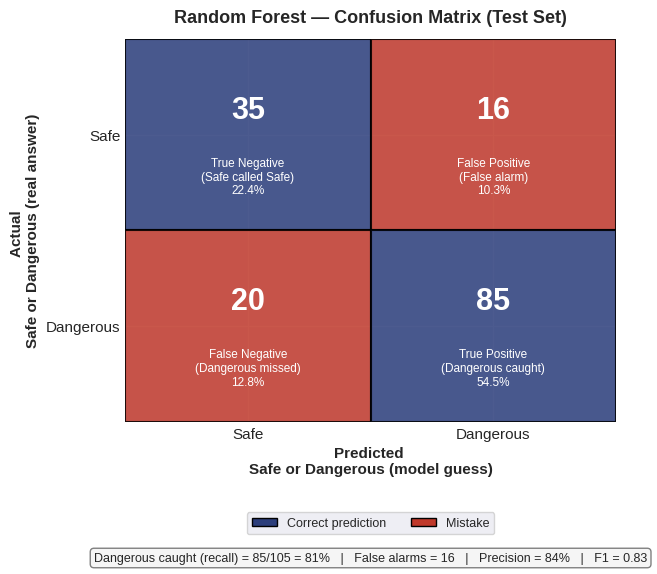

In [27]:
name = 'Random Forest'
cm = confusion_matrix(y_test, results[name]['y_pred'])
tn, fp, fn, tp = cm.ravel()
total = cm.sum()

labels = np.array([['True Negative\n(Safe called Safe)', 'False Positive\n(False alarm)'],
                   ['False Negative\n(Dangerous missed)', 'True Positive\n(Dangerous caught)']])
cell_colors = np.array([['#2C3E7B', '#C0392B'],
                        ['#2C3E7B'.replace('#2C3E7B','#C0392B'), '#2C3E7B']])

fig, ax = plt.subplots(figsize=(6.6, 6.2))
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, facecolor=cell_colors[i, j],
                                   edgecolor='black', lw=1.5, alpha=0.85))
        ax.text(j, i-0.13, f'{cm[i, j]}', ha='center', va='center',
                fontsize=22, fontweight='bold', color='white')
        ax.text(j, i+0.22, f'{labels[i, j]}\n{cm[i, j]/total*100:.1f}%',
                ha='center', va='center', fontsize=8.5, color='white')

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Safe', 'Dangerous']); ax.set_yticklabels(['Safe', 'Dangerous'])
ax.set_xlabel('Predicted \nSafe or Dangerous (model guess)', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual \nSafe or Dangerous (real answer)', fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)
ax.set_title(f'{name} — Confusion Matrix (Test Set)', fontsize=13, fontweight='bold', pad=12)

rec = tp/(tp+fn); prec = tp/(tp+fp); f1 = 2*prec*rec/(prec+rec)
ax.legend(handles=[Patch(facecolor='#2C3E7B', edgecolor='black', label='Correct prediction'),
                   Patch(facecolor='#C0392B', edgecolor='black', label='Mistake')],
          loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=True, fontsize=9)
ax.text(0.5, -0.34,
        f'Dangerous caught (recall) = {tp}/{tp+fn} = {rec:.0%}   |   '
        f'False alarms = {fp}   |   Precision = {prec:.0%}   |   F1 = {f1:.2f}',
        transform=ax.transAxes, ha='center', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#F5F5F5', edgecolor='gray'))
plt.tight_layout(); plt.show()

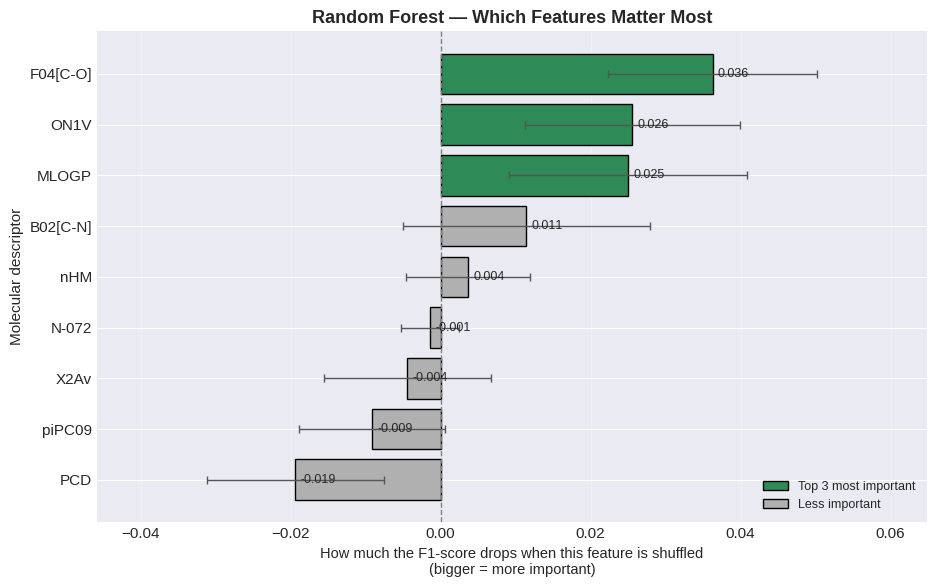

In [28]:
rf_best = results['Random Forest']['model']
perm = permutation_importance(rf_best, X_test, y_test, scoring='f1',
                              n_repeats=20, random_state=42, n_jobs=-1)
order = perm.importances_mean.argsort()
names = np.array(feature_cols)[order]
means = perm.importances_mean[order]
stds  = perm.importances_std[order]

# Highlight the top 3 features; grey out the rest
colors = ['#B0B0B0'] * len(means)
for k in range(1, 4):
    colors[-k] = '#2E8B57'

fig, ax = plt.subplots(figsize=(9.5, 6))
bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor='black',
               capsize=3, error_kw={'ecolor': '#555', 'lw': 1})
for b, m in zip(bars, means):   # label each bar with its value
    ax.text(m + max(means)*0.02, b.get_y()+b.get_height()/2, f'{m:.3f}',
            va='center', ha='left', fontsize=9)

ax.axvline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('How much the F1-score drops when this feature is shuffled\n(bigger = more important)',
              fontsize=10.5)
ax.set_ylabel('Molecular descriptor', fontsize=11)
ax.set_title('Random Forest — Which Features Matter Most', fontsize=13, fontweight='bold')
ax.margins(x=0.18)
ax.legend(handles=[Patch(facecolor='#2E8B57', edgecolor='black', label='Top 3 most important'),
                   Patch(facecolor='#B0B0B0', edgecolor='black', label='Less important')],
          loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

**Plot — Permutation Feature importance.**

1.   Removing one feature at a time (by scrambling its values) and check if the model gets worse.
2.    A big drop means that feature was important; no change means the model wasn't really using it.
3.    The longer the bar, the more the model depends on that feature , the green bars are the top three.
4.    The short black lines show how much the result changed each time we repeated the test.


## **2.3 XGBoost**

1.  This model also builds decision trees, but it builds them one after another, where each new tree tries to fix the errors the previous ones made.
2.  This "learn from mistakes" approach often makes it one of the most accurate models.
3.  Testing a few settings (how deep each tree goes, how fast the model learns, how many trees to build, and how much data each tree sees) and keep the combination that gives the best F1-score.

In [29]:
xgb_pipe = make_pipeline(xgb.XGBClassifier(
    random_state=42, eval_metric='logloss', tree_method='hist', n_jobs=-1))
xgb_grid = {'clf__n_estimators': [200, 400], 'clf__max_depth': [3, 5],
            'clf__learning_rate': [0.05, 0.1], 'clf__subsample': [0.8, 1.0],
            'clf__colsample_bytree': [0.8, 1.0]}
xgb_search = GridSearchCV(xgb_pipe, xgb_grid, scoring='f1', cv=cv, n_jobs=-1)
xgb_search.fit(X_train, y_train)
evaluate('XGBoost', xgb_search)

=== XGBoost ===
Best params : {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
CV F1 (train, 5-fold): 0.797
TEST  Precision=0.835  Recall=0.819  F1=0.827  ROC-AUC=0.817  PR-AUC=0.896


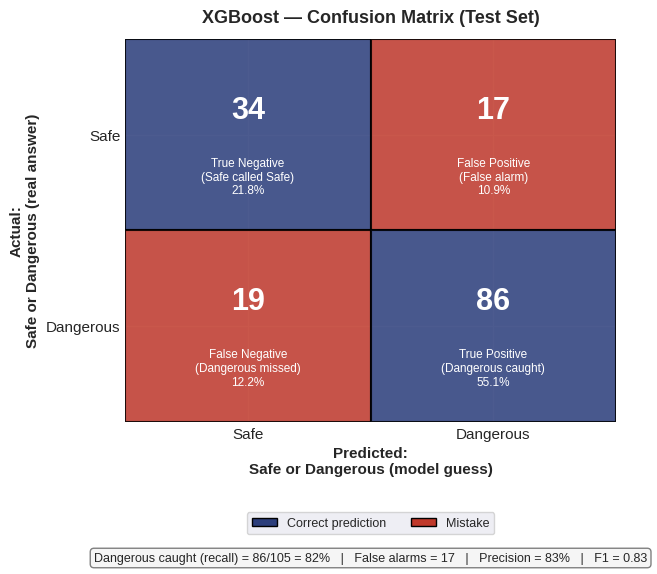

In [30]:
name = 'XGBoost'
cm = confusion_matrix(y_test, results[name]['y_pred'])
tn, fp, fn, tp = cm.ravel()
total = cm.sum()

labels = np.array([['True Negative\n(Safe called Safe)', 'False Positive\n(False alarm)'],
                   ['False Negative\n(Dangerous missed)', 'True Positive\n(Dangerous caught)']])
cell_colors = np.array([['#2C3E7B', '#C0392B'],
                        ['#C0392B', '#2C3E7B']])   # navy = correct, red = mistake

fig, ax = plt.subplots(figsize=(6.6, 6.2))
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, facecolor=cell_colors[i, j],
                                   edgecolor='black', lw=1.5, alpha=0.85))
        ax.text(j, i-0.13, f'{cm[i, j]}', ha='center', va='center',
                fontsize=22, fontweight='bold', color='white')
        ax.text(j, i+0.22, f'{labels[i, j]}\n{cm[i, j]/total*100:.1f}%',
                ha='center', va='center', fontsize=8.5, color='white')

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Safe', 'Dangerous']); ax.set_yticklabels(['Safe', 'Dangerous'])
ax.set_xlabel('Predicted:\nSafe or Dangerous (model guess)', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual:\nSafe or Dangerous (real answer)', fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)
ax.set_title(f'{name} — Confusion Matrix (Test Set)', fontsize=13, fontweight='bold', pad=12)

rec = tp/(tp+fn); prec = tp/(tp+fp); f1 = 2*prec*rec/(prec+rec)
ax.legend(handles=[Patch(facecolor='#2C3E7B', edgecolor='black', label='Correct prediction'),
                   Patch(facecolor='#C0392B', edgecolor='black', label='Mistake')],
          loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=True, fontsize=9)
ax.text(0.5, -0.34,
        f'Dangerous caught (recall) = {tp}/{tp+fn} = {rec:.0%}   |   '
        f'False alarms = {fp}   |   Precision = {prec:.0%}   |   F1 = {f1:.2f}',
        transform=ax.transAxes, ha='center', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#F5F5F5', edgecolor='gray'))
plt.tight_layout(); plt.show()